# Chapter 5. Quantum LSTM — 시계열 예측

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 3**

## 학습 목표
- 양자 회로를 RNN cell로 사용해 시계열 예측
- 합성 사인파에서 hidden state 전파 학습
- 양자 RNN과 고전 RNN의 학습 곡선 비교

In [2]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)

## 5.1 합성 시계열 데이터
두 주파수의 합으로 이루어진 사인파를 생성한다.

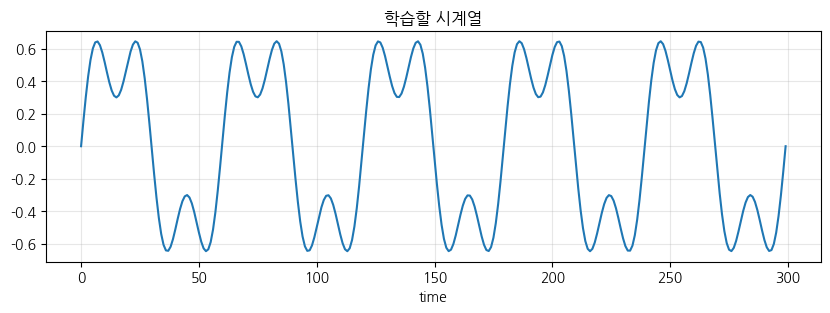

X: torch.Size([292, 8, 1]), y: torch.Size([292, 1])


In [3]:
def make_series(n=300):
    t = np.linspace(0, 10 * np.pi, n)
    return 0.6 * np.sin(t) + 0.3 * np.sin(3 * t)

series = make_series()
plt.figure(figsize=(10, 3))
plt.plot(series)
plt.title('학습할 시계열')
plt.xlabel('time'); plt.grid(alpha=0.3); plt.show()

# Sliding window로 (input_seq, target) 쌍 생성
window = 8
X_seq = np.array([series[i:i + window] for i in range(len(series) - window)])
y_seq = series[window:]
X_seq = torch.tensor(X_seq, dtype=torch.float32).unsqueeze(-1)  # (N, window, 1)
y_seq = torch.tensor(y_seq, dtype=torch.float32).unsqueeze(-1)
print(f'X: {X_seq.shape}, y: {y_seq.shape}')

## 5.2 Quantum RNN cell
양자 회로가 (x_t, h_{t-1})을 받아 새로운 h_t를 생성한다.

In [4]:
n_q = 4
dev = qml.device('default.qubit', wires=n_q)

@qml.qnode(dev, interface='torch')
def q_cell(inputs, weights):
    # inputs: (x_t와 h_{t-1}을 합쳐 4차원)
    qml.AngleEmbedding(inputs, wires=range(n_q), rotation='Y')
    qml.BasicEntanglerLayers(weights, wires=range(n_q))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_q)]

qlayer = qml.qnn.TorchLayer(q_cell, {'weights': (2, n_q)})

class QuantumRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(1, 1)  # x_t projection
        self.qcell = qlayer
        self.output = nn.Linear(n_q, 1)
        self.hidden_size = n_q

    def forward(self, x_seq):
        # x_seq: (batch, T, 1)
        batch = x_seq.size(0)
        h = torch.zeros(batch, self.hidden_size)
        # 시간 step별 처리
        T = x_seq.size(1)
        for t_idx in range(T):
            x_t = self.input_proj(x_seq[:, t_idx, :])  # (batch, 1)
            # 입력: x_t (1차원) + h의 첫 3개 차원 결합 → 4차원
            combined = torch.cat([x_t, h[:, :n_q - 1]], dim=1)
            h = self.qcell(combined)
        return self.output(h)

qrnn = QuantumRNN()
print(qrnn)

QuantumRNN(
  (input_proj): Linear(in_features=1, out_features=1, bias=True)
  (qcell): <Quantum Torch Layer: func=q_cell>
  (output): Linear(in_features=4, out_features=1, bias=True)
)


## 5.3 비교용 고전 GRU

In [5]:
class ClassicalGRU(nn.Module):
    def __init__(self, hidden_size=4):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x_seq):
        _, h = self.gru(x_seq)
        return self.output(h.squeeze(0))

gru = ClassicalGRU()
print(f'GRU 파라미터: {sum(p.numel() for p in gru.parameters())}')
print(f'QRNN 파라미터: {sum(p.numel() for p in qrnn.parameters())}')

GRU 파라미터: 89
QRNN 파라미터: 15


## 5.4 학습 (sample만 - 시간 절약)

Classical GRU 학습...
Quantum RNN 학습...


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


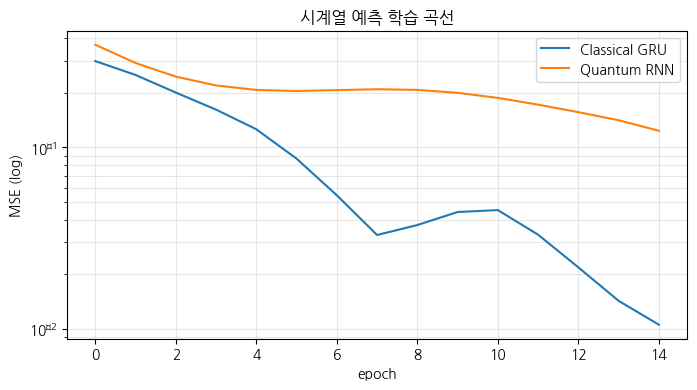

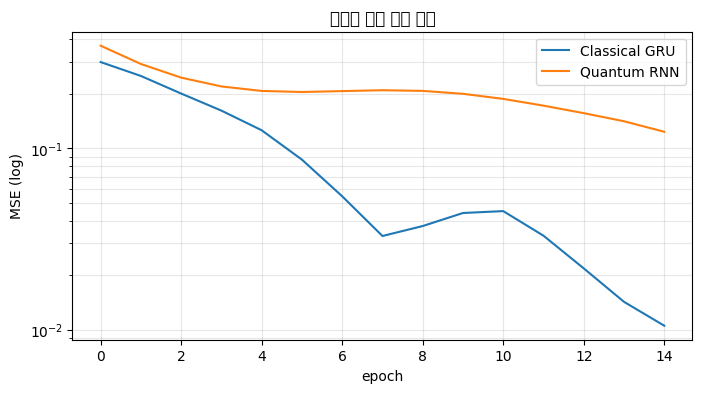

In [6]:
# 시간 절약을 위해 일부 샘플로 학습
N_train = 80
X_train = X_seq[:N_train]
y_train = y_seq[:N_train]

def train_seq_model(model, X, y, epochs=15, lr=0.05):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []
    for ep in range(epochs):
        opt.zero_grad()
        pred = model(X)
        loss = ((pred - y) ** 2).mean()
        loss.backward()
        opt.step()
        hist.append(loss.item())
    return hist

print('Classical GRU 학습...')
h_gru = train_seq_model(gru, X_train, y_train)
print('Quantum RNN 학습...')
h_qrnn = train_seq_model(qrnn, X_train, y_train)

plt.figure(figsize=(8, 4))
plt.semilogy(h_gru, label='Classical GRU')
plt.semilogy(h_qrnn, label='Quantum RNN')
plt.xlabel('epoch'); plt.ylabel('MSE (log)')
plt.title('시계열 예측 학습 곡선')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.show()

## 5.5 예측 결과 시각화

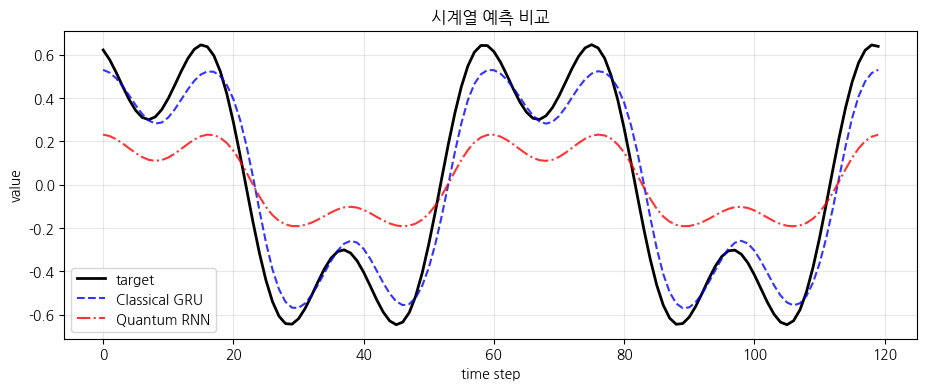

In [7]:
with torch.no_grad():
    pred_qrnn = qrnn(X_seq[:120]).squeeze().numpy()
    pred_gru = gru(X_seq[:120]).squeeze().numpy()

plt.figure(figsize=(11, 4))
plt.plot(y_seq[:120].squeeze(), 'k-', label='target', lw=2)
plt.plot(pred_gru, 'b--', label='Classical GRU', alpha=0.8)
plt.plot(pred_qrnn, 'r-.', label='Quantum RNN', alpha=0.8)
plt.xlabel('time step'); plt.ylabel('value')
plt.title('시계열 예측 비교')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5.6 정리
- Quantum RNN = 양자 회로가 cell 역할, hidden state는 측정값으로 전달
- 적은 파라미터로 시계열의 비선형 패턴 학습 가능
- 긴 시퀀스에서는 vanishing gradient에 주의 (고전 RNN과 동일한 문제)